In [1]:
import pandas as pd

sales_pipeline = pd.read_csv("sales_pipeline.csv")
accounts = pd.read_csv("accounts.csv")
products = pd.read_csv("products.csv")

In [2]:
sales_pipeline.shape, accounts.shape, products.shape

((8800, 8), (85, 9), (7, 3))

In [4]:
sales_pipeline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   object 
 1   sales_agent     8800 non-null   object 
 2   product         8800 non-null   object 
 3   account         7375 non-null   object 
 4   deal_stage      8800 non-null   object 
 5   engage_date     8300 non-null   object 
 6   close_date      6711 non-null   object 
 7   close_value     6711 non-null   float64
dtypes: float64(1), object(7)
memory usage: 550.1+ KB


In [5]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account           85 non-null     object 
 1   sector            85 non-null     object 
 2   year_established  85 non-null     int64  
 3   revenue           85 non-null     float64
 4   employees         85 non-null     int64  
 5   office_location   85 non-null     object 
 6   subsidiary_of     15 non-null     object 
 7   Unnamed: 7        0 non-null      float64
 8   Unnamed: 8        1 non-null      float64
dtypes: float64(3), int64(2), object(4)
memory usage: 6.1+ KB


In [6]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   product      7 non-null      object
 1   series       7 non-null      object
 2   sales_price  7 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 296.0+ bytes


In [7]:
print("Sales Pipeline Missing Values")
sales_pipeline.isnull().sum()
print("Accounts Missing Values")
accounts.isnull().sum()
print("Products Missing Values")
products.isnull().sum()

Sales Pipeline Missing Values
Accounts Missing Values
Products Missing Values


product        0
series         0
sales_price    0
dtype: int64

In [8]:
print("Sales Pipeline Duplicates:", sales_pipeline.duplicated().sum())
print("Accounts Duplicates:", accounts.duplicated().sum())
print("Products Duplicates:", products.duplicated().sum())

Sales Pipeline Duplicates: 0
Accounts Duplicates: 0
Products Duplicates: 0


In [9]:
sales_pipeline["engage_date"] = pd.to_datetime(sales_pipeline["engage_date"])
sales_pipeline["close_date"] = pd.to_datetime(sales_pipeline["close_date"])

In [10]:
sales_pipeline[["engage_date", "close_date"]].dtypes

engage_date    datetime64[ns]
close_date     datetime64[ns]
dtype: object

In [11]:
sales_pipeline["days_to_close"] = (
    sales_pipeline["close_date"] - sales_pipeline["engage_date"]
).dt.days

In [12]:
sales_pipeline["days_to_close"].describe()

count    6711.000000
mean       47.985397
std        41.057665
min         1.000000
25%         8.000000
50%        45.000000
75%        85.000000
max       138.000000
Name: days_to_close, dtype: float64

In [13]:
sales_pipeline.groupby("deal_stage")["days_to_close"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
deal_stage,,,,,
Engaging,0,NaN,NaN,NaN,NaN
Lost,2473,41.48,14.0,1.0,138.0
Prospecting,0,NaN,NaN,NaN,NaN
Won,4238,51.78,57.0,1.0,138.0


In [14]:
sales_pipeline.groupby("deal_stage")["close_value"].agg(
    ["count", "sum", "mean"]
).round(2)

,count,sum,mean
deal_stage,,,
Engaging,0,0.0,NaN
Lost,2473,0.0,0.00
Prospecting,0,0.0,NaN
Won,4238,10005534.0,2360.91


In [17]:
agent_performance = (
    sales_pipeline.groupby("sales_agent")
    .agg(
        opportunities=("opportunity_id", "count"),
        won_opportunities=("deal_stage", lambda x: (x == "Won").sum()),
        lost_opportunities=("deal_stage", lambda x: (x=="Lost").sum()),
        won_sales_value=("close_value", "sum")
    )
    .sort_values("won_sales_value", ascending=False)
)

agent_performance

,opportunities,won_opportunities,lost_opportunities,won_sales_value
sales_agent,,,,
Darcel Schlecht,747,349,204,1153214.0
Vicki Laflamme,451,221,126,478396.0
Kary Hendrixson,438,209,126,454298.0
Cassey Cress,346,163,98,450489.0
Donn Cantrell,275,158,117,445860.0
Reed Clapper,237,155,82,438336.0
Zane Levy,349,161,100,430068.0
Corliss Cosme,310,150,79,421036.0
James Ascencio,267,135,71,413533.0


In [18]:
agent_performance["win_rate"]=(
    agent_performance["won_opportunities"] / 
    (agent_performance["won_opportunities"] + 
     agent_performance["lost_opportunities"])
) * 100

agent_performance["win_rate"] = agent_performance["win_rate"].round(2)

agent_performance

,opportunities,won_opportunities,lost_opportunities,won_sales_value,win_rate
sales_agent,,,,,
Darcel Schlecht,747,349,204,1153214.0,63.11
Vicki Laflamme,451,221,126,478396.0,63.69
Kary Hendrixson,438,209,126,454298.0,62.39
Cassey Cress,346,163,98,450489.0,62.45
Donn Cantrell,275,158,117,445860.0,57.45
Reed Clapper,237,155,82,438336.0,65.40
Zane Levy,349,161,100,430068.0,61.69
Corliss Cosme,310,150,79,421036.0,65.50
James Ascencio,267,135,71,413533.0,65.53


In [20]:
product_performance = (
    sales_pipeline.groupby("product")
    .agg(
        Opportunities=("opportunity_id", "count"),
        won_opportunities = ("deal_stage", lambda x: (x == "Won").sum()),
        lost_opportunities= ("deal_stage", lambda x: (x == "Lost").sum()),
        sales_value=("close_value", "sum"),
        avg_deal_value=("close_value", "mean")
    )
    .sort_values("sales_value", ascending=False)
)

product_performance

,Opportunities,won_opportunities,lost_opportunities,sales_value,avg_deal_value
product,,,,,
GTXPro,1480,729,418,3510578.0,3060.660854
GTX Plus Pro,968,479,266,2629651.0,3529.732886
MG Advanced,1412,654,430,2216387.0,2044.637454
GTX Plus Basic,1383,653,398,705275.0,671.051380
GTX Basic,1866,915,521,499263.0,347.676184
GTK 500,40,15,10,400612.0,16024.480000
MG Special,1651,793,430,43768.0,35.787408


In [22]:
product_performance["win_rate"] = (
    product_performance["won_opportunities"] /
    (product_performance["won_opportunities"] +
     product_performance["lost_opportunities"])
) * 100

product_performance["win_rate"] = product_performance["win_rate"].round(2)

product_performance

,Opportunities,won_opportunities,lost_opportunities,sales_value,avg_deal_value,win_rate
product,,,,,,
GTXPro,1480,729,418,3510578.0,3060.660854,63.56
GTX Plus Pro,968,479,266,2629651.0,3529.732886,64.30
MG Advanced,1412,654,430,2216387.0,2044.637454,60.33
GTX Plus Basic,1383,653,398,705275.0,671.051380,62.13
GTX Basic,1866,915,521,499263.0,347.676184,63.72
GTK 500,40,15,10,400612.0,16024.480000,60.00
MG Special,1651,793,430,43768.0,35.787408,64.84


In [28]:
sector_performance = (
    sales_pipeline.merge(
        accounts[["account", "sector", "employees", "revenue"]],
        on = "account",
        how="left"
    )
    .groupby("sector")
    .agg(
        opprotunites = ("opportunity_id", "count"),
        won_opprotunities = ("deal_stage", lambda x: (x=="Won").sum()),
        lost_opprotunities = ("deal_stage", lambda x: (x=="Lost").sum()),
        sales_value = ("close_value", "sum")
    )
    .sort_values("sales_value", ascending=False)
)

sector_performance

,opprotunites,won_opprotunities,lost_opprotunities,sales_value
sector,,,,
retail,1397,799,468,1867528.0
technolgy,1165,671,387,1515487.0
medical,1051,592,358,1359595.0
software,757,450,254,1077934.0
finance,678,375,238,950908.0
marketing,674,404,219,922321.0
entertainment,451,260,142,689007.0
telecommunications,501,285,171,653574.0
services,390,223,129,533006.0


In [29]:
sector_performance["win_rate"] = (
    sector_performance["won_opprotunities"] / 
    (sector_performance["won_opprotunities"] + 
     sector_performance["lost_opprotunities"])
) * 100

sector_performance["win_rate"] = sector_performance["win_rate"].round(2)

sector_performance

,opprotunites,won_opprotunities,lost_opprotunities,sales_value,win_rate
sector,,,,,
retail,1397,799,468,1867528.0,63.06
technolgy,1165,671,387,1515487.0,63.42
medical,1051,592,358,1359595.0,62.32
software,757,450,254,1077934.0,63.92
finance,678,375,238,950908.0,61.17
marketing,674,404,219,922321.0,64.85
entertainment,451,260,142,689007.0,64.68
telecommunications,501,285,171,653574.0,62.50
services,390,223,129,533006.0,63.35


In [31]:
account_performance = (
    sales_pipeline.groupby("account")
    .agg(
        opportunities = ("opportunity_id", "count"),
        won_opportunities = ("deal_stage", lambda x: (x=="Won").sum()),
        lost_opportunities = ("deal_stage", lambda x: (x=="Lost").sum()),
        sales_value = ("close_value", "sum"),
        avg_deal_value = ("close_value", "mean")
    )
    .sort_values("sales_value", ascending=False)
)

account_performance.head(10)

,opportunities,won_opportunities,lost_opportunities,sales_value,avg_deal_value
account,,,,,
Kan-code,196,115,72,341455.0,1825.962567
Konex,178,108,63,269245.0,1574.532164
Condax,170,105,54,206410.0,1298.176101
Cheers,98,57,33,198020.0,2200.222222
Hottechi,200,111,82,194957.0,1010.139896
Goodsilron,95,65,23,182522.0,2074.113636
Treequote,116,65,41,176751.0,1667.462264
Warephase,106,70,31,170046.0,1683.623762
Xx-holding,87,48,31,169357.0,2143.759494


In [32]:
account_performance["win_rate"] = (
    account_performance["won_opportunities"] / 
    (account_performance["won_opportunities"] + 
     account_performance["lost_opportunities"])
) * 100

account_performance["win_rate"] = account_performance["win_rate"].round(2)

account_performance.head(10)

,opportunities,won_opportunities,lost_opportunities,sales_value,avg_deal_value,win_rate
account,,,,,,
Kan-code,196,115,72,341455.0,1825.962567,61.50
Konex,178,108,63,269245.0,1574.532164,63.16
Condax,170,105,54,206410.0,1298.176101,66.04
Cheers,98,57,33,198020.0,2200.222222,63.33
Hottechi,200,111,82,194957.0,1010.139896,57.51
Goodsilron,95,65,23,182522.0,2074.113636,73.86
Treequote,116,65,41,176751.0,1667.462264,61.32
Warephase,106,70,31,170046.0,1683.623762,69.31
Xx-holding,87,48,31,169357.0,2143.759494,60.76


In [34]:
monthly_sales = (
    sales_pipeline
    .groupby(sales_pipeline["close_date"].dt.to_period("M"))
    .agg(
        opportunities = ("opportunity_id", "count"),
        sales_value = ("close_value", "sum")
    )
    .reset_index()
)

monthly_sales["close_date"] = monthly_sales["close_date"].astype(str)

monthly_sales

,close_date,opportunities,sales_value
0,2017-03,647,1134672.0
1,2017-04,586,721932.0
2,2017-05,805,1025713.0
3,2017-06,641,1338466.0
4,2017-07,627,696932.0
5,2017-08,785,1050059.0
6,2017-09,635,1235264.0
7,2017-10,566,731980.0
8,2017-11,768,938943.0
9,2017-12,651,1131573.0


In [36]:
top_products = (
    product_performance
    .sort_values("sales_value", ascending=False)
    .head(10)
    )

top_products

,Opportunities,won_opportunities,lost_opportunities,sales_value,avg_deal_value,win_rate
product,,,,,,
GTXPro,1480,729,418,3510578.0,3060.660854,63.56
GTX Plus Pro,968,479,266,2629651.0,3529.732886,64.30
MG Advanced,1412,654,430,2216387.0,2044.637454,60.33
GTX Plus Basic,1383,653,398,705275.0,671.051380,62.13
GTX Basic,1866,915,521,499263.0,347.676184,63.72
GTK 500,40,15,10,400612.0,16024.480000,60.00
MG Special,1651,793,430,43768.0,35.787408,64.84


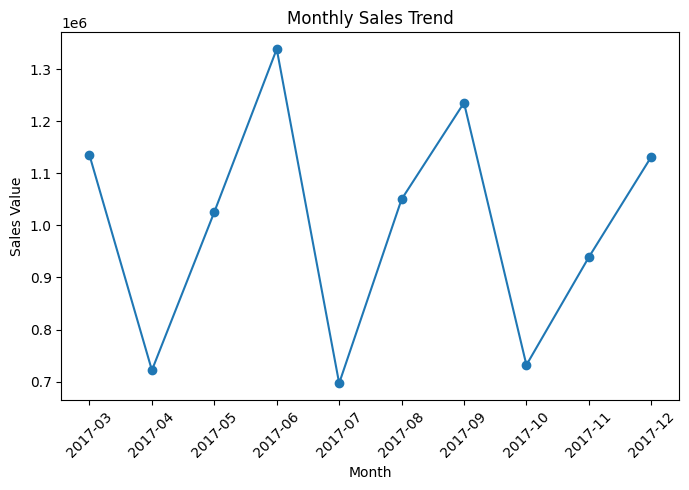

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    monthly_sales["close_date"],
    monthly_sales["sales_value"],
    marker = "o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

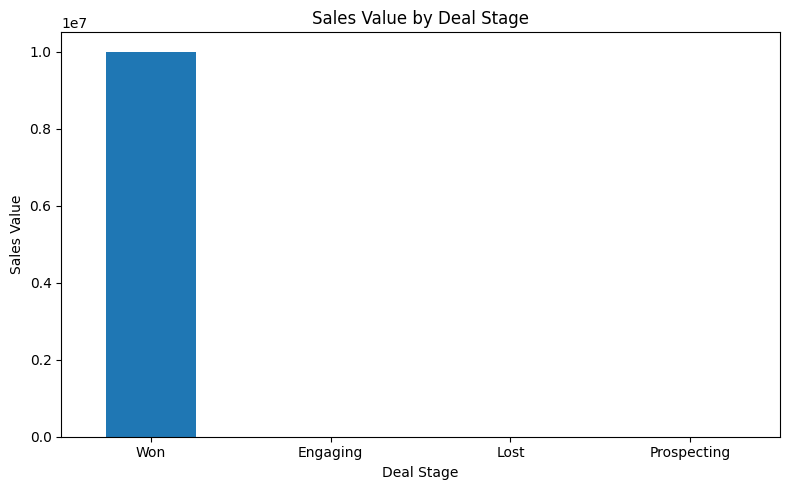

In [41]:
stage_sales = (
    sales_pipeline
    .groupby("deal_stage")["close_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

stage_sales.plot(kind="bar")

plt.title("Sales Value by Deal Stage")
plt.xlabel("Deal Stage")
plt.ylabel("Sales Value")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [42]:
print("===== CRM SALES BUSINESS INSIGHTS =====\n")

print("1. Deal Stage Performance:")
print(
    sales_pipeline.groupby("deal_stage")["close_value"]
    .sum()
    .sort_values(ascending=False)
)

print("\n2. Top 5 Sales Agents by Sales Value:")
print(
    agent_performance["won_sales_value"]
    .head(5)
)

print("\n3. Top 5 Products by Sales Value:")
print(
    product_performance["sales_value"]
    .head(5)
)

print("\n4. Top 5 Sectors by Sales Value:")
print(
    sector_performance["sales_value"]
    .head(5)
)

print("\n5. Top 5 Accounts by Sales Value:")
print(
    account_performance["sales_value"]
    .head(5)
)

===== CRM SALES BUSINESS INSIGHTS =====

1. Deal Stage Performance:
deal_stage
Won            10005534.0
Engaging              0.0
Lost                  0.0
Prospecting           0.0
Name: close_value, dtype: float64

2. Top 5 Sales Agents by Sales Value:
sales_agent
Darcel Schlecht    1153214.0
Vicki Laflamme      478396.0
Kary Hendrixson     454298.0
Cassey Cress        450489.0
Donn Cantrell       445860.0
Name: won_sales_value, dtype: float64

3. Top 5 Products by Sales Value:
product
GTXPro            3510578.0
GTX Plus Pro      2629651.0
MG Advanced       2216387.0
GTX Plus Basic     705275.0
GTX Basic          499263.0
Name: sales_value, dtype: float64

4. Top 5 Sectors by Sales Value:
sector
retail       1867528.0
technolgy    1515487.0
medical      1359595.0
software     1077934.0
finance       950908.0
Name: sales_value, dtype: float64

5. Top 5 Accounts by Sales Value:
account
Kan-code    341455.0
Konex       269245.0
Condax      206410.0
Cheers      198020.0
Hottechi    194